# Convergence testing

Pick a single graph, run TorusMDS on it with the stress trajectory recorded at
every convergence check, and plot the curve. Useful for sanity-checking
`tol`/`window_iters`/`max_iters` choices directly, rather than inferring them
from `termination_reason` alone across a whole batch of graphs.

Requires `record_history=True` support in `MDSTorusProjector.fit_transform`
(added alongside the `tol` early-stopping fix -- see `modules/projector.py`).
Convergence is judged by the coefficient of variation (std/mean) over the
trailing `window_iters` iterations of stress checks, not a single
point-to-point comparison -- `step_pos` (the position step size) decays but
never reaches exactly zero, so the stress trajectory never truly settles to a
fixed point. `window_iters` is expressed in iterations, not "number of
checks": checks land every `chunk_epochs` iterations (a batching/dispatch
granularity, unrelated to convergence), so a checks-count default doesn't mean
anything on its own without also knowing `chunk_epochs` -- iterations do.
Alpha (and, for `learn_mode=alpha_aspect`, `r0`/`r1`) is EMA-smoothed and then
frozen entirely once it's been stable for a full window (`alpha_freeze_tol`,
decoupled from `tol`) -- freezing removes its noise from the trajectory
instead of merely damping it, once it's no longer moving.

In [1]:
import os
import sys
import time

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath('..'))
from modules.experiment_runner import ASPECT_INIT_VARIANTS, SPECTRAL_INIT_ONLY_METHOD, load_graph
from modules.graphio import apsp_distance_matrix
from modules.initialization import find_fundamental_torus_directions, rect_torus_init_from_spectral
from modules.projector import LearnMode, MDSTorusProjector
from modules.visualization import plot_embedding_with_torus_edges

## Load a graph

Pick **one** of the loaders below and assign its result to `G`. The cache/layouts
loaders need a real path on disk; the synthetic ones work with no setup, useful
for a quick sanity check.

In [2]:
def from_cache(cache_dir: str, exp_idx: int) -> nx.Graph:
    """Load one graph by exp_idx from a stage_sbm.py/stage_grg.py-style cache
    (data/sbm_cache/<tier>, data/grg_cache/<tier>) or a suitesparse cache."""
    return load_graph(os.path.join(cache_dir, f"graph_{exp_idx}.npz"))


def from_layouts_shard(shard_dir: str, exp_idx: int) -> nx.Graph:
    """Load one graph already persisted by a real embed run
    (layouts/<family>/.../shard_N/graphs/graph_<idx>.npz)."""
    return load_graph(os.path.join(shard_dir, "graphs", f"graph_{exp_idx}.npz"))


def synthetic_sbm(n: int = 500, k: int = 5, p_in: float = 0.8, p_out: float = 0.05, seed: int = 0) -> nx.Graph:
    sizes = [n // k] * k
    sizes[-1] += n - sum(sizes)
    probs = [[p_in if i == j else p_out for j in range(k)] for i in range(k)]
    G = nx.stochastic_block_model(sizes, probs, seed=seed)
    if not nx.is_connected(G):
        comps = list(nx.connected_components(G))
        for i in range(len(comps) - 1):
            G.add_edge(next(iter(comps[i])), next(iter(comps[i + 1])))
    return nx.convert_node_labels_to_integers(G)


def synthetic_grg(n: int = 500, epsilon: float = 0.15, seed: int = 0) -> nx.Graph:
    rng = np.random.default_rng(seed)
    pts = rng.uniform(0.0, 1.0, size=(n, 2))
    from scipy.spatial.distance import cdist
    adj = cdist(pts, pts) <= epsilon
    np.fill_diagonal(adj, False)
    G = nx.from_numpy_array(adj.astype(np.uint8))
    if not nx.is_connected(G):
        comps = list(nx.connected_components(G))
        for i in range(len(comps) - 1):
            G.add_edge(next(iter(comps[i])), next(iter(comps[i + 1])))
    return nx.convert_node_labels_to_integers(G)


# --- pick one -- n=500 keeps the full notebook (single run + 9-method comparison
# + 4-point tol sweep, ~14 SGD runs total) to well under a minute; bump it toward
# the real experiment's tiers (up to 10000) once you know what you're looking for. ---
G = synthetic_sbm(n=500, k=5, seed=0)
# G = synthetic_grg(n=500, epsilon=0.15, seed=0)
# G = from_cache("../data/sbm_cache/1000_3000", exp_idx=0)
# G = from_layouts_shard("../layouts/sbm_normalized/1000_3000/shard_0", exp_idx=0)

print(f"n={G.number_of_nodes()}, m={G.number_of_edges()}")
D, _ = apsp_distance_matrix(G)

n=500, m=24945


## Single-run convergence curve

`record_history=True` logs `(iteration, stress)` at every `chunk_epochs`-spaced
check regardless of `tol` (recording never changes the stopping decision itself
-- confirmed to produce bit-identical `n_iter`/`termination_reason` with or
without it).

In [3]:
def run_and_track(D, label, init=None, learn_mode=LearnMode.ALPHA, max_iters=10000,
                   tol=1e-4, window_iters=320, stress_mode="raw", batch_size=4096, seed=0,
                   alpha_freeze_tol=1e-3):
    proj = MDSTorusProjector(projection="wrap")
    t0 = time.perf_counter()
    X = proj.fit_transform(
        D, max_iters=max_iters, seed=seed, stress_mode=stress_mode,
        learn_mode=learn_mode, tol=tol, window_iters=window_iters,
        batch_size=batch_size, init=init, record_history=True,
        alpha_freeze_tol=alpha_freeze_tol,
    )
    elapsed = time.perf_counter() - t0
    history = proj.stress_history_ or []
    return {
        "label": label, "X": X, "proj": proj, "elapsed": elapsed,
        "n_iter": proj.n_iter_, "reason": proj.termination_reason_,
        "final_stress": history[-1][1] if history else None,
        "history": history,
    }


def plot_histories(runs, title="Convergence", logy=True):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for r in runs:
        if not r["history"]:
            continue
        iters, stress = [h[0] for h in r["history"]], [h[1] for h in r["history"]]
        ax.plot(iters, stress, marker="o", markersize=3, label=r["label"])
        ax.axvline(r["n_iter"], color=ax.lines[-1].get_color(), linestyle="--", alpha=0.3)
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("iteration")
    ax.set_ylabel("stress (fixed subsample)")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(linestyle="--", alpha=0.3)
    fig.tight_layout()
    return fig, ax


def plot_r0_r1(runs, title="Aspect ratio (r0, r1) over training"):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for r in runs:
        if not r["history"] or len(r["history"][0]) < 4:
            continue
        iters = [h[0] for h in r["history"]]
        r0s = [h[2] for h in r["history"]]
        ax.plot(iters, r0s, marker="o", markersize=3, label=f"{r['label']} (r0)")
    ax.set_xlabel("iteration")
    ax.set_ylabel("r0")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(linestyle="--", alpha=0.3)
    fig.tight_layout()
    return fig, ax


def summary_table(runs) -> pd.DataFrame:
    return pd.DataFrame([
        {"label": r["label"], "n_iter": r["n_iter"], "reason": r["reason"],
         "elapsed_s": round(r["elapsed"], 3), "final_stress": r["final_stress"]}
        for r in runs
    ])

n_iter=800  reason=tolerance  elapsed=0.90s  final_stress=0.113873


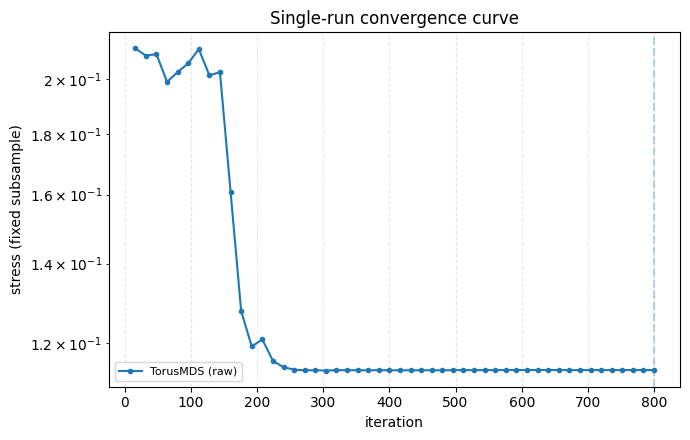

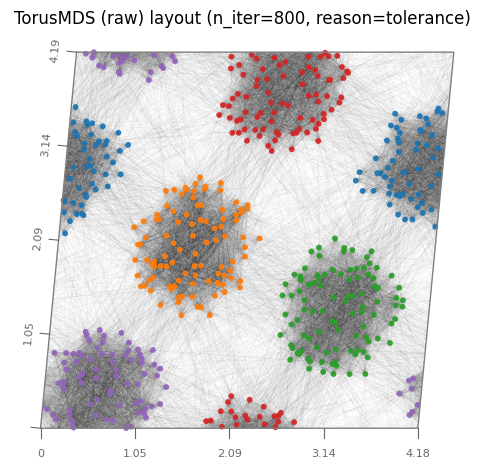

In [4]:
run = run_and_track(D, label="TorusMDS (raw)", learn_mode=LearnMode.PARALLELOGRAM,
                    max_iters=10000, tol=1e-4, stress_mode="normalized")
print(f"n_iter={run['n_iter']}  reason={run['reason']}  elapsed={run['elapsed']:.2f}s  "
      f"final_stress={run['final_stress']:.6g}")
plot_histories([run], title="Single-run convergence curve")
plt.show()

# Sanity check: does the resulting layout actually look reasonable, not just
# "converged" by the numeric criterion? `run["proj"]` already has alpha_/r0_/
# r1_/theta_ populated by fit_transform, so it can be passed directly as the
# `torus=` argument -- no need to rebuild those into a separate namespace.
# Colors by ground-truth block/community membership when the graph has one
# (e.g. synthetic_sbm's nodes carry a 'block' attribute); plain otherwise.
colors = cmap = vmin = vmax = None
if all('block' in G.nodes[node] for node in G.nodes()):
    colors = np.array([G.nodes[node]['block'] for node in G.nodes()])
    cmap, vmin, vmax = 'tab10', 0, 9
fig, ax = plt.subplots(figsize=(6, 6))
plot_embedding_with_torus_edges(X=run["X"], G=G, torus=run["proj"], ax=ax,
                                 s=10, edge_alpha=0.03, colors=colors, cmap=cmap, vmin=vmin, vmax=vmax)
ax.set_title(f"{run['label']} layout (n_iter={run['n_iter']}, reason={run['reason']})")
plt.show()

## Compare the methods actually used in the pipeline

Same graph, same `D`, run through `TorusMDS` plus every current
`ASPECT_INIT_VARIANTS` entry and the spectral-init-only method -- mirrors what
`run_embeddings` does per graph, including sharing one spectral decomposition
across every "smart" variant (computed once below, reused by all of them, same
as `modules/experiment_runner.py`'s per-graph cache).

In [5]:
TOL = 1e-4
WINDOW_ITERS = 320
MAX_ITERS = 10000
STRESS_MODE = "normalized"   # matches the current experiment config

spectral_result = None
try:
    spectral_result = find_fundamental_torus_directions(D / D.max())
except Exception as e:
    print(f"spectral init failed: {e}")

runs = []

# Plain TorusMDS (learn_mode='alpha', fixed unit-square torus)
runs.append(run_and_track(D, "TorusMDS", learn_mode=LearnMode.ALPHA,
                          max_iters=MAX_ITERS, tol=TOL, window_iters=WINDOW_ITERS, stress_mode=STRESS_MODE))

# Spectral init only, no SGD -- single point, not a curve
if spectral_result is not None:
    t0 = time.perf_counter()
    coords, r0, r1 = rect_torus_init_from_spectral(spectral_result)
    spectral_only_elapsed = time.perf_counter() - t0
    print(f"{SPECTRAL_INIT_ONLY_METHOD}: r0={r0:.4f} r1={r1:.4f} elapsed={spectral_only_elapsed:.4f}s (no SGD)")

# Every ASPECT_INIT_VARIANTS entry (learn_mode='alpha_aspect', jointly learns r0/r1)
for name, (init_mode, batch_multiplier, init_scale) in ASPECT_INIT_VARIANTS.items():
    if init_mode == "smart":
        if spectral_result is None:
            continue
        init, _, _ = rect_torus_init_from_spectral(spectral_result)
    else:
        init = 0.5 + (np.random.RandomState(0).rand(D.shape[0], 2) - 0.5) / init_scale
    runs.append(run_and_track(
        D, name, init=init, learn_mode=LearnMode.ALPHA_ASPECT,
        max_iters=MAX_ITERS, tol=TOL, window_iters=WINDOW_ITERS, stress_mode=STRESS_MODE,
        batch_size=4096 * batch_multiplier,
    ))

summary_table(runs)

TorusMDS_spectral_init: r0=1.6608 r1=1.1143 elapsed=0.0001s (no SGD)


,label,n_iter,reason,elapsed_s,final_stress
0,TorusMDS,832,tolerance,0.483,0.114577
1,TorusMDS_smart_1x,1648,tolerance,0.952,0.115810
2,TorusMDS_smart_1x_scale2,1648,tolerance,0.935,0.115810
3,TorusMDS_smart_1x_scale4,1648,tolerance,0.916,0.115810
4,TorusMDS_smart_1x_scale10,1648,tolerance,0.914,0.115810
5,TorusMDS_random_1x,1264,tolerance,0.710,0.111450
6,TorusMDS_random_1x_scale2,1264,tolerance,0.707,0.112489
7,TorusMDS_random_1x_scale4,1168,tolerance,0.692,0.113506
8,TorusMDS_random_1x_scale10,1120,tolerance,0.644,0.108839


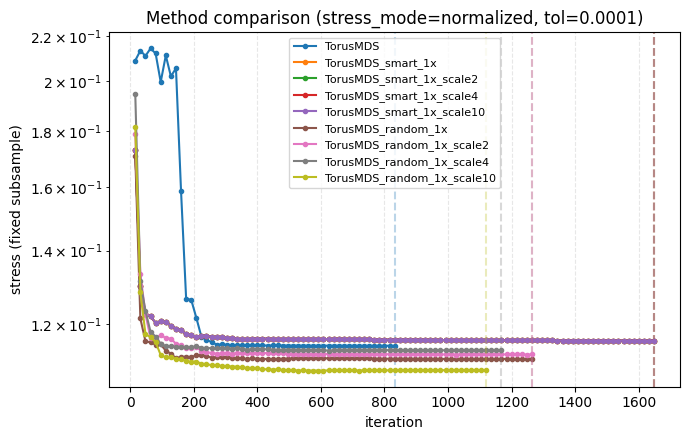

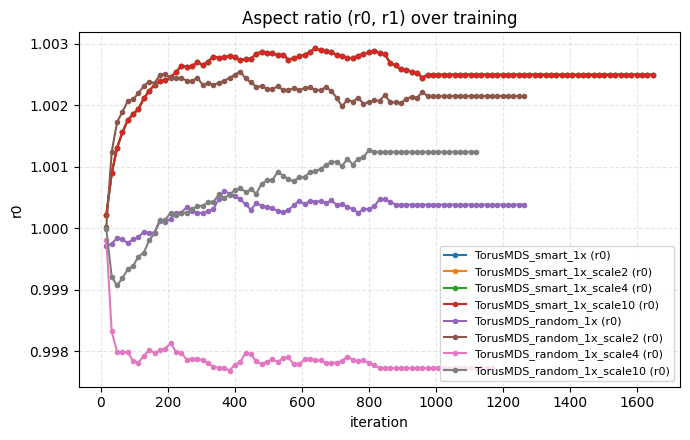

In [6]:
plot_histories(runs, title=f"Method comparison (stress_mode={STRESS_MODE}, tol={TOL})")
plt.show()

# r0 for the alpha_aspect runs -- shows whether the aspect ratio is still
# visibly drifting/jittering late in training (relevant before the geom_lr EMA
# and freeze; now mainly useful to confirm it settles and stays frozen).
plot_r0_r1([r for r in runs if r["proj"].r0_ is not None and r["label"] != "TorusMDS"])
plt.show()

## Ablation: does geometry-freezing actually help, or was it the chunk_epochs decrease?

Isolates the freeze mechanism from the `chunk_epochs`/`window_iters` change
that happened alongside it. Both runs below use the current defaults
(`chunk_epochs=16`, `window_iters=320`, `tol=1e-4`) -- the only thing toggled
is `alpha_freeze_tol`: `1e-3` (current default, freeze ON) vs `0.0` (freeze
OFF -- the freeze condition is `CV < alpha_freeze_tol`, and CV is a
std/mean ratio that's always `>= 0`, so `CV < 0.0` can never fire; this
disables freezing without touching `modules/projector.py` at all).

In [7]:
ablation_runs = []

# Plain TorusMDS (learn_mode=alpha) -- freeze only removes alpha re-profiling noise here.
for freeze_tol, tag in [(1e-3, "freeze ON"), (0.0, "freeze OFF")]:
    ablation_runs.append(run_and_track(
        D, f"TorusMDS ({tag})", learn_mode=LearnMode.ALPHA,
        max_iters=MAX_ITERS, tol=TOL, window_iters=WINDOW_ITERS, stress_mode=STRESS_MODE,
        alpha_freeze_tol=freeze_tol,
    ))

# smart_1x_scale2-equivalent (learn_mode=alpha_aspect) -- freeze also removes
# the geom_lr r0/r1 update's noise here, so any effect should be larger.
if spectral_result is not None:
    init, _, _ = rect_torus_init_from_spectral(spectral_result)
    for freeze_tol, tag in [(1e-3, "freeze ON"), (0.0, "freeze OFF")]:
        ablation_runs.append(run_and_track(
            D, f"smart_1x_scale2 ({tag})", init=init, learn_mode=LearnMode.ALPHA_ASPECT,
            max_iters=MAX_ITERS, tol=TOL, window_iters=WINDOW_ITERS, stress_mode=STRESS_MODE,
            alpha_freeze_tol=freeze_tol,
        ))

# random_1x_scale2-equivalent -- random (not spectral) init means r0/r1 start
# further from their eventual fit, so the geom_lr update has more distance to
# cover and (per the tol-sweep/method-comparison tables above) this variant
# has historically taken longer to settle than the smart-init ones -- the
# best chance for freezing's noise removal to actually matter.
random_init = 0.5 + (np.random.RandomState(0).rand(D.shape[0], 2) - 0.5) / 2
for freeze_tol, tag in [(1e-3, "freeze ON"), (0.0, "freeze OFF")]:
    ablation_runs.append(run_and_track(
        D, f"random_1x_scale2 ({tag})", init=random_init, learn_mode=LearnMode.ALPHA_ASPECT,
        max_iters=MAX_ITERS, tol=TOL, window_iters=WINDOW_ITERS, stress_mode=STRESS_MODE,
        alpha_freeze_tol=freeze_tol,
    ))

summary_table(ablation_runs)

,label,n_iter,reason,elapsed_s,final_stress
0,TorusMDS (freeze ON),832,tolerance,0.482,0.114577
1,TorusMDS (freeze OFF),832,tolerance,0.529,0.114576
2,smart_1x_scale2 (freeze ON),1648,tolerance,0.960,0.115810
3,smart_1x_scale2 (freeze OFF),1744,tolerance,1.008,0.115810
4,random_1x_scale2 (freeze ON),1264,tolerance,0.741,0.112489
5,random_1x_scale2 (freeze OFF),1248,tolerance,0.759,0.112482


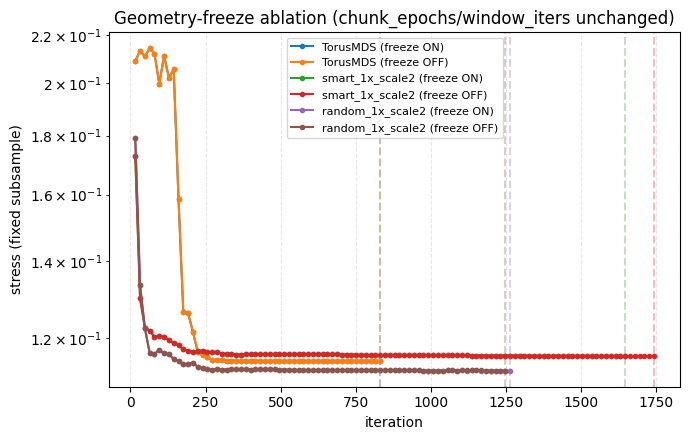

In [8]:
plot_histories(ablation_runs, title="Geometry-freeze ablation (chunk_epochs/window_iters unchanged)")
plt.show()

## `tol` sweep

Same graph, one representative config (`smart_1x_scale2`-equivalent init), varying
`tol` -- directly shows the time-vs-thoroughness tradeoff behind the `1e-6` -> `1e-4`
default change.

In [9]:
tol_runs = []
if spectral_result is not None:
    init, _, _ = rect_torus_init_from_spectral(spectral_result)
    for tol in [1e-3, 1e-4, 1e-5, 1e-6]:
        tol_runs.append(run_and_track(
            D, f"tol={tol:g}", init=init, learn_mode=LearnMode.ALPHA_ASPECT,
            max_iters=MAX_ITERS, tol=tol, window_iters=WINDOW_ITERS, stress_mode=STRESS_MODE,
        ))
else:
    print("spectral init unavailable for this graph -- skipping sweep")

summary_table(tol_runs)

,label,n_iter,reason,elapsed_s,final_stress
0,tol=0.001,592,tolerance,0.366,0.116179
1,tol=0.0001,1648,tolerance,0.983,0.115810
2,tol=1e-05,4576,tolerance,2.616,0.115746
3,tol=1e-06,10000,max_iters,5.638,0.115727


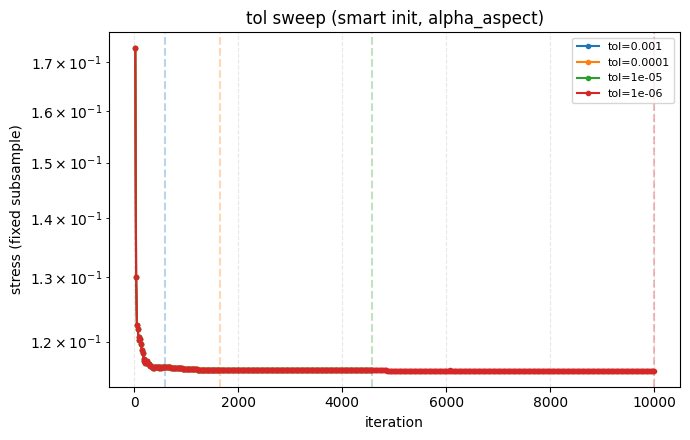

In [10]:
if tol_runs:
    plot_histories(tol_runs, title="tol sweep (smart init, alpha_aspect)")
    plt.show()
